In [ ]:
import numpy as np
import torch
from torchvision.datasets import MNIST

import matplotlib.pyplot as plt
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
plt.rcParams.update({'font.size': 15, 'font.family': 'serif', 'mathtext.fontset' : 'cm'})
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
directory = '/data/'
train = MNIST(directory, train=True)
test = MNIST(directory, train=False)

In [3]:
from scipy.ndimage import interpolation

# Deskewing code from https://fsix.github.io/mnist/Deskewing.html
def moments(image):
    c0,c1 = np.mgrid[:image.shape[0],:image.shape[1]] # A trick in numPy to create a mesh grid
    totalImage = np.sum(image) #sum of pixels
    m0 = np.sum(c0*image)/totalImage #mu_x
    m1 = np.sum(c1*image)/totalImage #mu_y
    m00 = np.sum((c0-m0)**2*image)/totalImage #var(x)
    m11 = np.sum((c1-m1)**2*image)/totalImage #var(y)
    m01 = np.sum((c0-m0)*(c1-m1)*image)/totalImage #covariance(x,y)
    mu_vector = np.array([m0,m1]) # Notice that these are \mu_x, \mu_y respectively
    covariance_matrix = np.array([[m00,m01],[m01,m11]]) # Do you see a similarity between the covariance matrix
    return mu_vector, covariance_matrix

def deskew(image):
    c,v = moments(image)
    alpha = v[0,1]/v[0,0]
    affine = np.array([[1,0],[alpha,1]])
    ocenter = np.array(image.shape)/2.0
    offset = c-np.dot(affine,ocenter)
    return interpolation.affine_transform(image,affine,offset=offset), affine, offset

In [4]:
train_deskewed = []
test_deskewed = []
train_affines = []
train_offsets = []
test_affines = []
test_offsets = []
for image, label in train:
    image = np.array(image) / 255.0
    image, affine, offset = deskew(image)
    train_deskewed.append((image, label))
    train_affines.append(affine)
    train_offsets.append(offset)
for image, label in test:
    image = np.array(image) / 255.0
    image, affine, offset = deskew(image)
    test_deskewed.append((image, label))
    test_affines.append(affine)
    test_offsets.append(offset)

/tmp/ipykernel_2226870/4114643111.py:22: DeprecationWarning: Please import `affine_transform` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  return interpolation.affine_transform(image,affine,offset=offset), affine, offset


In [5]:
average_intensities = [np.mean(image) for image, _ in train_deskewed]

In [6]:
from scipy.ndimage import rotate
import math

# Apply the transform to the train and test datasets and keep track of rotations
train_rotated = []
train_rotations = []
for image, label in train_deskewed:
    angle = float(torch.rand(1)) * 180  # Get random angle
    train_rotations.append(math.radians(angle))  # Convert to radians
    train_rotated.append((rotate(image, angle, reshape=False), label))

In [7]:
from skimage.morphology import skeletonize
from skimage.measure import regionprops, label

stroke_widths = []

for image, _ in train_deskewed:
    skeleton = skeletonize(image > 0)  # Binarize and skeletonize the image
    labeled_skeleton = label(skeleton)  # Label connected components in the skeleton
    props = regionprops(labeled_skeleton, intensity_image=image)
    
    if props:  # Ensure there are regions to calculate stroke width
        stroke_width = np.mean([prop.mean_intensity for prop in props])
    else:
        stroke_width = 0  # Default to 0 if no regions are found
    
    stroke_widths.append(stroke_width)

In [8]:
from scipy.spatial import ConvexHull

diameters = []

for image, _ in train:
    points = np.column_stack(np.nonzero(image))  # Get non-zero points (y, x)
    
    if len(points) > 2:  # ConvexHull requires at least 3 points
        hull = ConvexHull(points)
        pw_distances = [np.linalg.norm(points[hull.vertices[i]] - points[hull.vertices[j]])
                        for i in range(len(hull.vertices)) for j in range(i + 1, len(hull.vertices))]
        diameter = max(pw_distances)
    else:
        diameter = 0  # Default to 0 if there are not enough points
    
    diameters.append(diameter)

In [9]:
from gudhi import CubicalComplex

H_1_first = []
H_1_second = []
for i in range(len(train_deskewed)):
    cplx = CubicalComplex(vertices = -np.array(train_deskewed[i][0]))
    cplx.compute_persistence(homology_coeff_field=2, min_persistence=0.5)
    H_1_intervals = cplx.persistence_intervals_in_dimension(1)
    H_1_pers = [death-birth for [birth, death] in H_1_intervals]
    if len(H_1_pers) > 0:
        H_1_first.append(H_1_pers[0])
    else:
        H_1_first.append(0)
    if len(H_1_pers) > 1:
        H_1_second.append(H_1_pers[1])
    else:
        H_1_second.append(0)

In [10]:
train_rotated_flattened = np.array([np.array(train_rotated[i][0]).flatten() for i in range(len(train_rotated))])

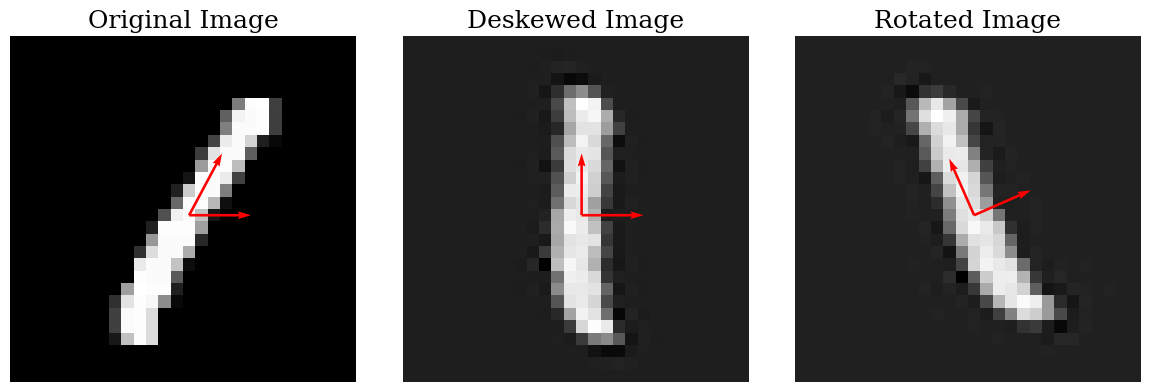

Angle: 0.4147860081992963 rad
Stroke Width: 0.09371178824884362
Average Intensity: 0.08570978723349262
Diameter: 23.021728866442675


In [11]:
# %matplotlib ipympl

i = 3  # Replace with the desired index
image = np.array(train_rotated[i][0])
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original image
original_image = np.array(train[i][0])
axes[0].imshow(original_image, cmap='gray')
axes[0].quiver(original_image.shape[0] / 2, original_image.shape[1] / 2,
               5 * np.cos(0),  # No rotation for the original image
               -5 * np.sin(0),
               angles='xy', scale_units='xy', scale=1, color='red')
axes[0].quiver(original_image.shape[0] / 2, original_image.shape[1] / 2,
               5 * np.cos(train_affines[i][1,0]+np.pi/2),  # No rotation for the original image
               -5 * np.sin(0+np.pi/2),
               angles='xy', scale_units='xy', scale=1, color='red')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Deskewed image
deskewed_image = np.array(train_deskewed[i][0])
axes[1].imshow(deskewed_image, cmap='gray')
axes[1].quiver(deskewed_image.shape[0] / 2, deskewed_image.shape[1] / 2,
               5 * np.cos(0),  # No rotation for the original image
               -5 * np.sin(0),
               angles='xy', scale_units='xy', scale=1, color='red')
axes[1].quiver(deskewed_image.shape[0] / 2, deskewed_image.shape[1] / 2,
               5 * np.cos(0+np.pi/2),  # No rotation for the original image
               -5 * np.sin(0+np.pi/2),
               angles='xy', scale_units='xy', scale=1, color='red')
axes[1].set_title("Deskewed Image")
axes[1].axis('off')

# Rotated image
axes[2].imshow(image, cmap='gray')
axes[2].quiver(image.shape[0] / 2, image.shape[1] / 2,
               5 * np.cos(train_rotations[i]),
               -5 * np.sin(train_rotations[i]),
               angles='xy', scale_units='xy', scale=1, color='red')
axes[2].quiver(image.shape[0] / 2, image.shape[1] / 2,
               5 * np.cos(train_rotations[i]+np.pi/2),
               -5 * np.sin(train_rotations[i]+np.pi/2),
               angles='xy', scale_units='xy', scale=1, color='red')
axes[2].set_title("Rotated Image")
axes[2].axis('off')

plt.tight_layout()
fig.savefig('../images/deskewed_mnist_example.png', dpi=300)
plt.show()
print(f"Angle: {train_rotations[i]} rad")
print(f"Stroke Width: {stroke_widths[i]}")
print(f"Average Intensity: {average_intensities[i]}")
print(f"Diameter: {diameters[i]}")
# print(f"H_1: {H_1_first[i], H_1_second[i]}")

In [ ]:
from sklearn.manifold import SpectralEmbedding
from umap import UMAP

F = np.column_stack((train_rotations, average_intensities, stroke_widths, diameters, H_1_first, H_1_second))
F_names = ['Rotation', 'Avg. Intensity', 'Stroke Width', 'Diameter', r'$H_1$ First', r'$H_1$ Second']

m = 3

# svd = TruncatedSVD(n_components=32)
# X_svd = svd.fit_transform(train_rotated_flattened)
# X = X_svd

# spec = SpectralEmbedding(n_components=m, affinity='rbf', gamma=0.1)
# X_spec = spec.fit_transform(train_rotated_flattened)
# X = X_spec

umap = UMAP(n_neighbors=16, n_components=m, min_dist=0.3, metric='euclidean', random_state=0)
X_umap = umap.fit_transform(train_rotated_flattened)
X = X_umap

/tmp/ipykernel_2226870/2343283256.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(train.targets)


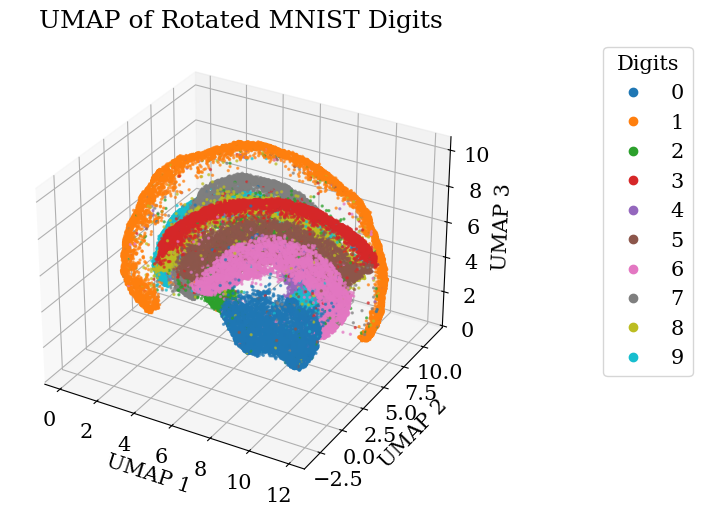

In [13]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(1,1,1, projection='3d')
targets = np.array(train.targets)

sc = ax.scatter(X[:,0], X[:,1], X[:,2], c=targets, cmap='tab10', s=2, alpha=0.6)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2'); ax.set_zlabel('UMAP 3')
ax.set_title('UMAP of Rotated MNIST Digits')
leg = ax.legend(*sc.legend_elements(), title="Digits", loc='upper right',
                 bbox_to_anchor=(1.5,1.0))
for h in leg.legend_handles:
    h.set_alpha(1)

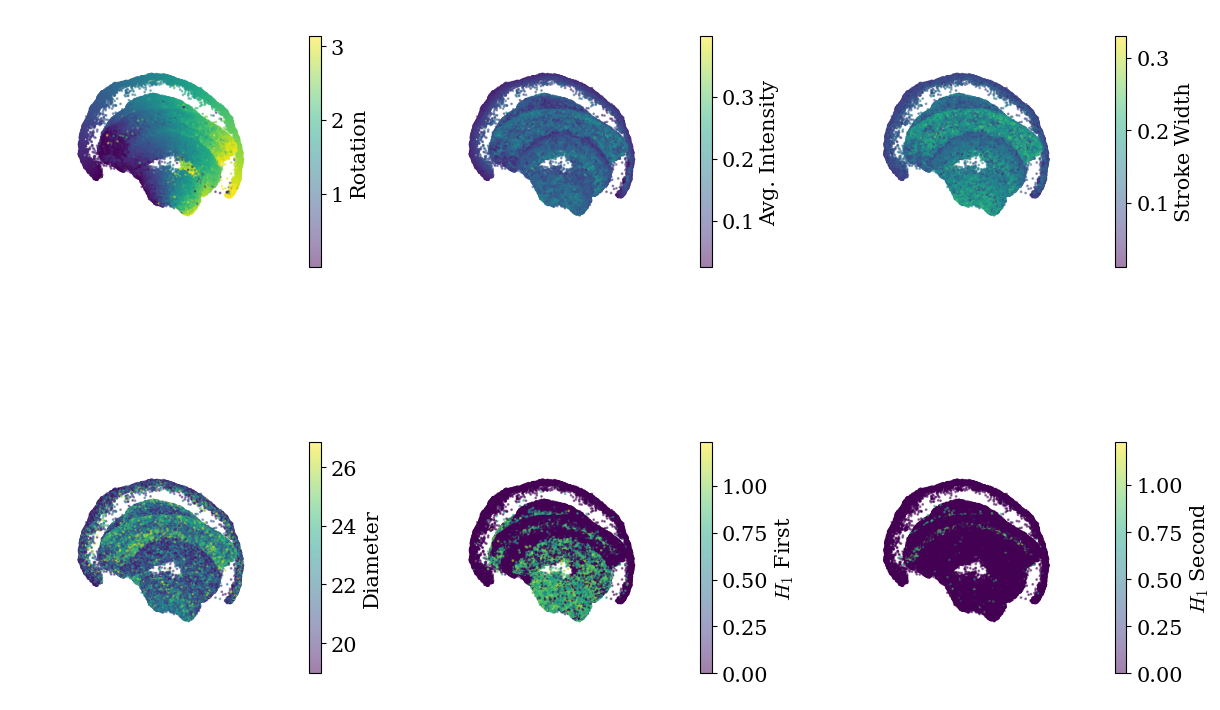

In [14]:
n_features = F.shape[1]  # should be 6 here
n_rows_small = 2
n_cols_small = int(np.ceil(n_features / n_rows_small))

fig = plt.figure(figsize=(5 * n_cols_small, 8), constrained_layout=True)
gs = fig.add_gridspec(
    n_rows_small, 
    n_cols_small + 1, 
    width_ratios=[1] + [1] * n_cols_small,
    wspace=0.05, hspace=0.05
)

# Small plots: embedding colored by each feature in F
for j in range(n_rows_small * n_cols_small):
    r, c = divmod(j, n_cols_small)
    ax = fig.add_subplot(gs[r, c], projection='3d')
    ax.axis('off')
    if j < n_features:
        sc = ax.scatter(
            X[:, 0], X[:, 1], X[:, 2],
            c=F[:, j], cmap='viridis', s=1, alpha=0.5
        )
        # ax.set_title(F_names[j])
        fig.colorbar(sc, ax=ax, shrink=0.6, label=F_names[j])
    else:
        ax.set_axis_off()
fig.savefig('../images/mnist_umap_embedding_colored.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import sys
sys.path.append('../')
from lego import lego

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import MultiTaskElasticNet
from sklearn.neighbors import kneighbors_graph
from local_ts_regression import lpca, run_ts_regression_smoothed

d = 2

r = 1.0
knn = 16
neighbor_graph = kneighbors_graph(X, knn, include_self=True)

trivial_basis = np.stack([np.eye(X.shape[1])] * X.shape[0], axis=0)
lpca_basis = lpca(X, d, neighbor_graph)
wlpca_basis = lpca(X, d, neighbor_graph, r=1.0)

lego_estimate = lego.lego(
    X,
    opts={'emb_dim': d, 'k_nn': knn}
)
lego_basis = lego_estimate['tang_basis']

Label: 5
Support Features: ['Rotation', 'Diameter']


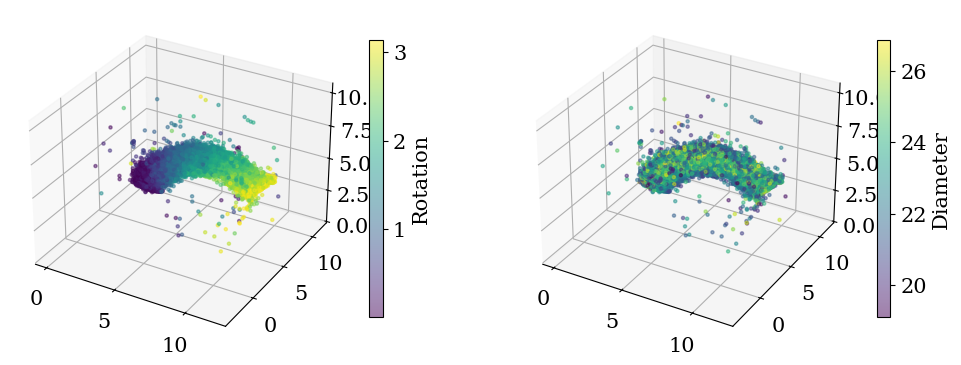

In [ ]:
d=2
index = 0

# tsbasis = trivial_basis
# tsbasis = lpca_basis
# tsbasis = wlpca_basis
tsbasis = lego_basis

normalizer = StandardScaler(with_mean=False)
regressor = MultiTaskElasticNet(alpha=0.5, l1_ratio=0.5, fit_intercept=False)
reg_coefs, proj = run_ts_regression_smoothed(X, F, index, neighbor_graph, tsbasis, regressor=regressor, d=d, gamma=1.0, k=1)
strengths = np.linalg.norm(reg_coefs, axis=0)
support = np.where(strengths > 0)[0]
class_indices = np.where(train.targets == train.targets[index])[0]
print(f'Label: {train.targets[index]}')
print(f'Support Features: {[F_names[i] for i in support]}')
fig = plt.figure(figsize=(12,6))
for i in range(len(support)):
    ax = fig.add_subplot(1, len(support), i+1, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c = 'gray', s=5, alpha=0.001)
    sc = ax.scatter(X[class_indices, 0], X[class_indices, 1], X[class_indices, 2], c = F[class_indices,support[i]], s=5, cmap='viridis', alpha=0.5)
    ax.scatter(X[index, 0], X[index, 1], X[index, 2], c = 'red', s=100, marker = 'o')
    fig.colorbar(sc, ax=ax, label=F_names[support[i]], shrink=0.6)

In [ ]:
supports = []
subsample = np.random.choice(X.shape[0], size=1000, replace=False)
for idx in subsample:
    reg_coefs, proj = run_ts_regression_smoothed(X, F, idx, neighbor_graph, tsbasis, regressor=regressor, d=d, gamma=1.0, k=1)
    strengths = np.linalg.norm(reg_coefs, axis=0)
    support = np.where(strengths > 0)[0]
    supports.append(support)

In [18]:
from collections import Counter
from itertools import combinations

# convert supports (list of arrays) to fixed-length tuples (pad with -1 or trim to length d)
def _to_tuple(s):
    arr = np.array(s, dtype=int)
    if arr.size >= d:
        return tuple(arr[:d].tolist())
    else:
        return tuple(list(arr.tolist()) + [-1] * (d - arr.size))

supports = np.array([_to_tuple(s) for s in supports])

labels = np.array(train.targets)[subsample]

d_tuple_counts_by_class = {}
feature_counts_by_class = {}
class_counts = Counter()

for lab, sup in zip(labels, supports):
    lab = int(lab)
    if lab not in d_tuple_counts_by_class:
        d_tuple_counts_by_class[lab] = Counter()
        feature_counts_by_class[lab] = Counter()
    d_tuple_counts_by_class[lab][tuple(sup)] += 1
    class_counts[lab] += 1
    for feat in sup:
        if feat >= 0:
            feature_counts_by_class[lab][int(feat)] += 1

/tmp/ipykernel_2226870/2083468910.py:14: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  labels = np.array(train.targets)[subsample]


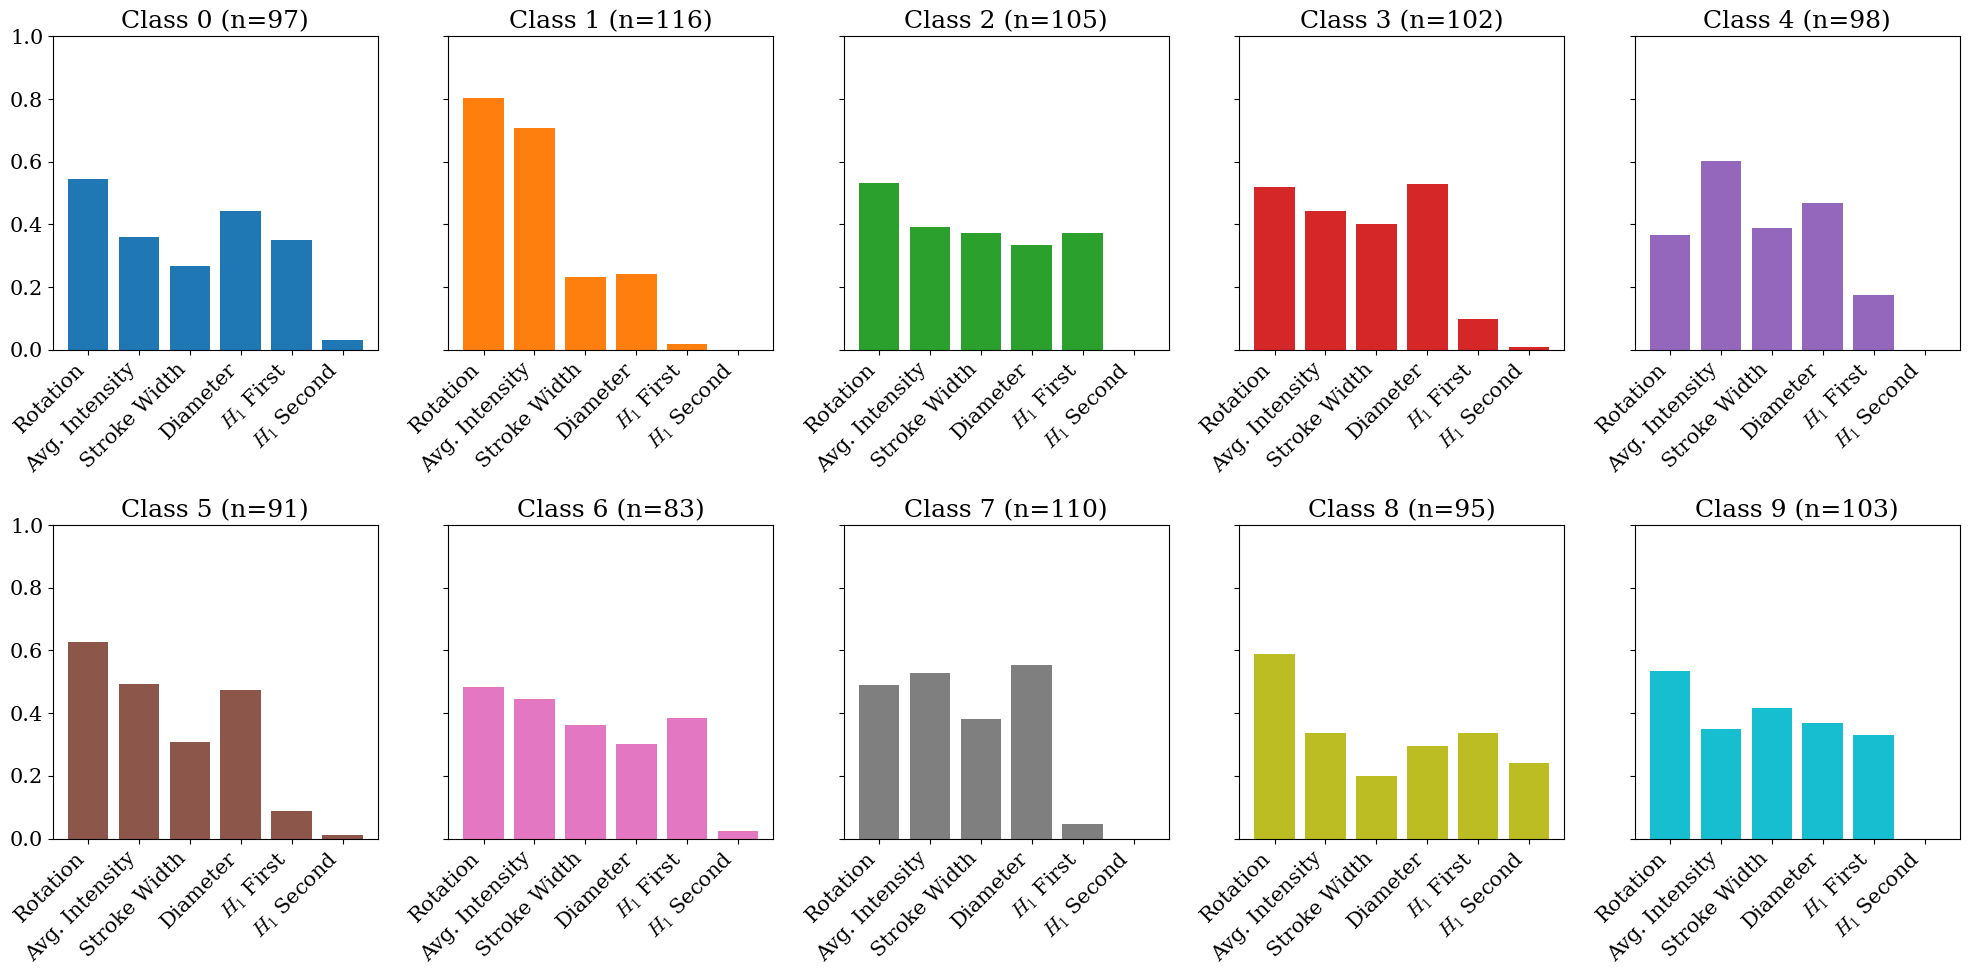

In [19]:
n_features = len(F_names)
n_classes = 10
cols = 5
rows = (n_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows), sharey=True)
axes = axes.ravel()

max_count = 0
for cnt in feature_counts_by_class.values():
    if cnt:
        max_count = max(max_count, max(cnt.values()))
if max_count == 0:
    max_count = 1

for cls in range(n_classes):
    ax = axes[cls]
    counts = [feature_counts_by_class.get(cls, {}).get(i, 0) for i in range(n_features)]
    ax.bar(range(n_features), [count / class_counts.get(cls,0) for count in counts], color=plt.cm.tab10(cls % 10))
    ax.set_xticks(range(n_features))
    ax.set_xticklabels(F_names, rotation=45, ha='right')
    ax.set_title(f"Class {cls} (n={class_counts.get(cls,0)})")
    ax.set_ylim(0, 1)

for ax in axes[n_classes:]:
    ax.axis('off')

plt.tight_layout()
plt.show()
fig.savefig('../images/mnist_explanations_by_class.pdf')

/tmp/ipykernel_2226870/168941958.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(train.targets)


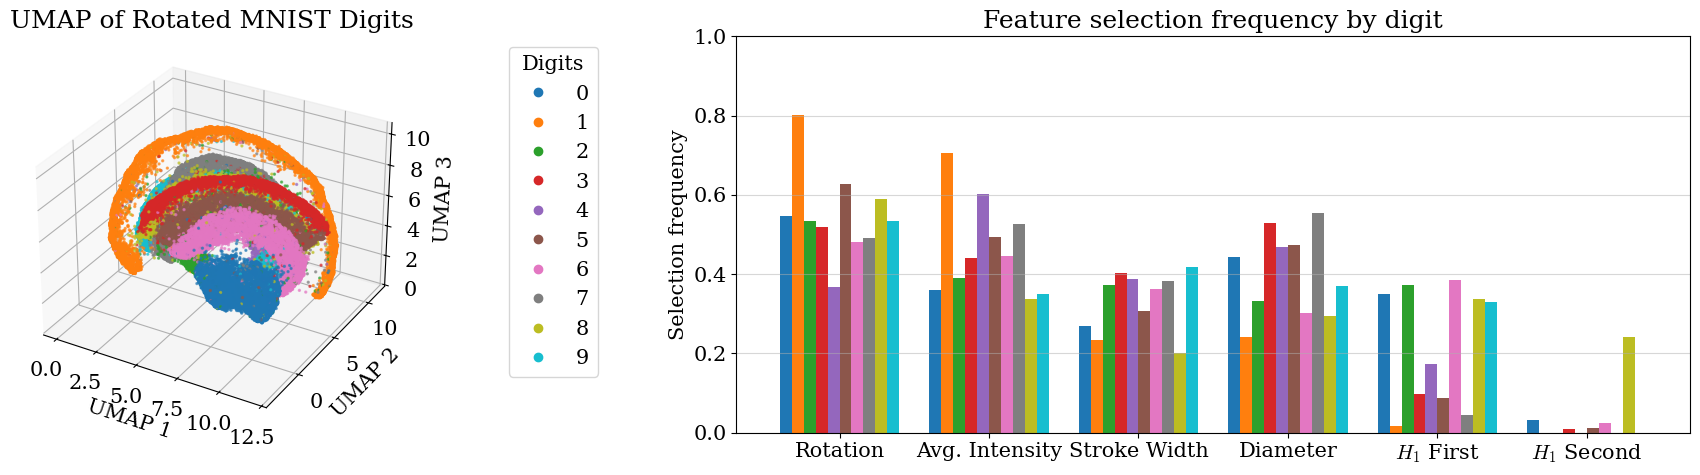

In [20]:
# Combined plot: left = 3D UMAP embedding, right = grouped bar chart of selection frequency per digit
fig = plt.figure(figsize=(20,5))
ax1 = fig.add_subplot(1,2,1, projection='3d')
targets = np.array(train.targets)

sc = ax1.scatter(X[:,0], X[:,1], X[:,2], c=targets, cmap='tab10', s=2, alpha=0.6)
ax1.set_xlabel('UMAP 1'); ax1.set_ylabel('UMAP 2'); ax1.set_zlabel('UMAP 3')
ax1.set_title('UMAP of Rotated MNIST Digits')
leg = ax1.legend(*sc.legend_elements(), title="Digits", loc='upper right',
                 bbox_to_anchor=(1.5,1.0))
for h in leg.legend_handles:
    h.set_alpha(1)
# ax1.view_init(azim=150, elev=30)

ax2 = fig.add_subplot(1,2,2)
n_digits = 10
n_features = F.shape[1]

# compute selection frequency per digit using feature_counts_by_class and class_counts (from subsample)
freqs = np.zeros((n_digits, n_features))
for d in range(n_digits):
    denom = class_counts.get(d, 0)
    counts = [feature_counts_by_class.get(d, {}).get(i, 0) for i in range(n_features)]
    if denom > 0:
        freqs[d] = np.array(counts) / denom
    else:
        freqs[d] = 0

x = np.arange(n_features)
width = 0.8 / n_digits
colors = [plt.cm.tab10(i) for i in range(n_digits)]
for d in range(n_digits):
    offset = (d - (n_digits-1)/2) * width
    ax2.bar(x + offset, freqs[d], width=width, color=colors[d], label=str(d))

ax2.set_xticks(x)
ax2.set_xticklabels(F_names)
ax2.set_ylabel('Selection frequency')
ax2.set_title('Feature selection frequency by digit')
ax2.set_ylim(0,1)
ax2.grid(axis='y', alpha=0.5)
# ax2.legend(title='Digit', bbox_to_anchor=(1.02,1), loc='upper left', ncol=1)

plt.tight_layout()
plt.subplots_adjust(wspace=0.05) 
fig.savefig('../images/mnist_feature_selection_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

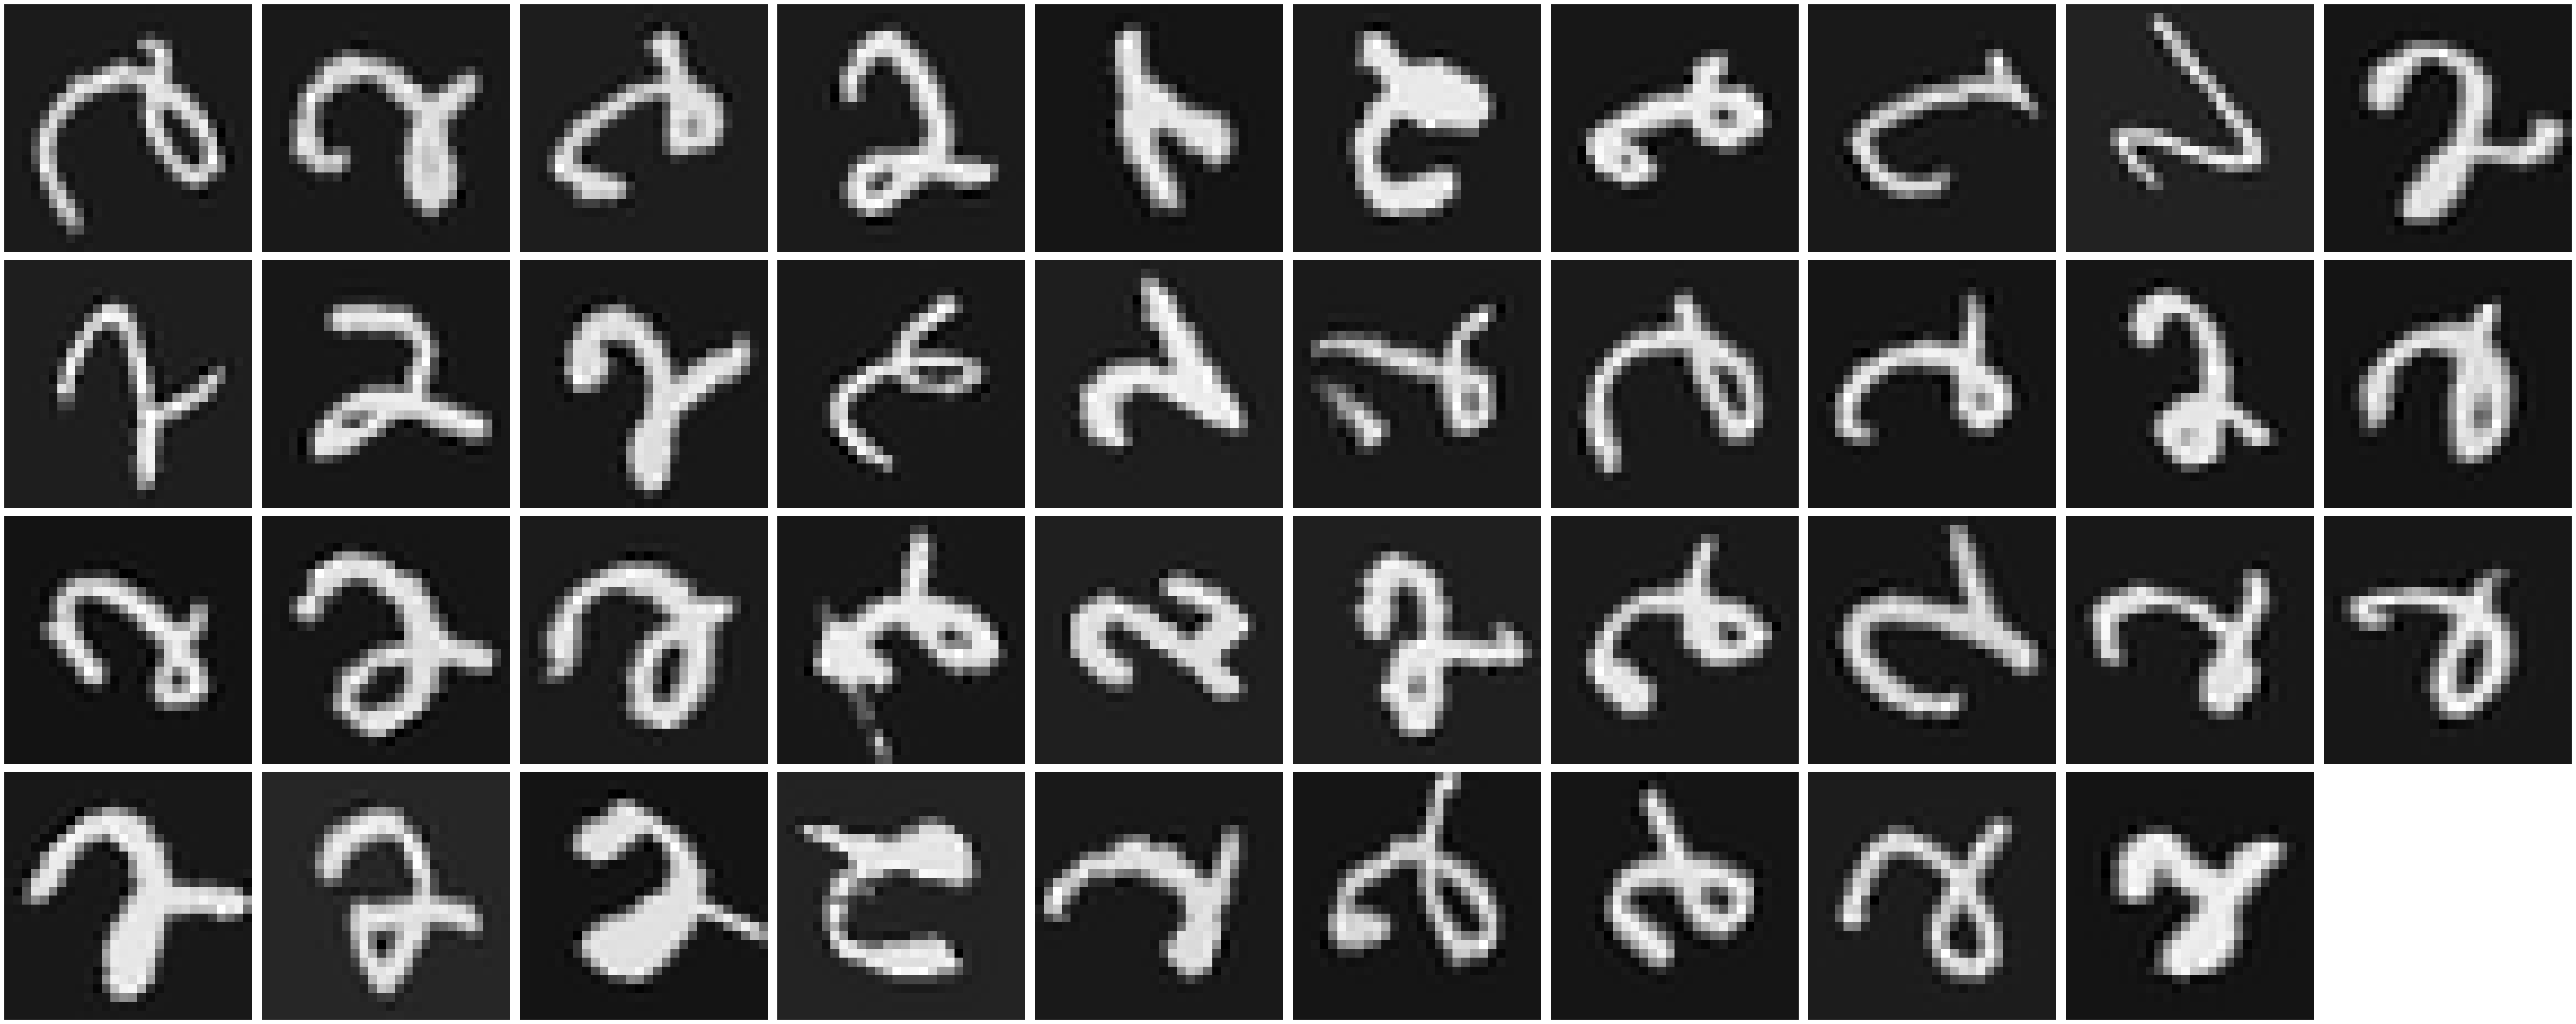

In [21]:
twos_with_homology = []
twos_with_homology_idx = []
for i, index in enumerate(subsample):
    if train.targets[index] == 2 and 4 in supports[i]:
        twos_with_homology.append(index)
        twos_with_homology_idx.append(i)

col_length = 10
n_rows = (len(twos_with_homology) + col_length - 1) // col_length
n_cols = min(col_length, len(twos_with_homology))
fig, ax = plt.subplots(figsize=(6*n_cols, 6*n_rows))
for i, index in enumerate(twos_with_homology):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(np.array(train_rotated[index][0]), cmap='gray')
    # plt.title(f"Explanation:\n" + ", ".join([F_names[j] for j in supports[twos_with_homology_idx[i]]]), fontsize=20)
    plt.axis('off')
ax.set_axis_off()
plt.tight_layout()
fig.savefig('../images/mnist_twos_with_homology.pdf')

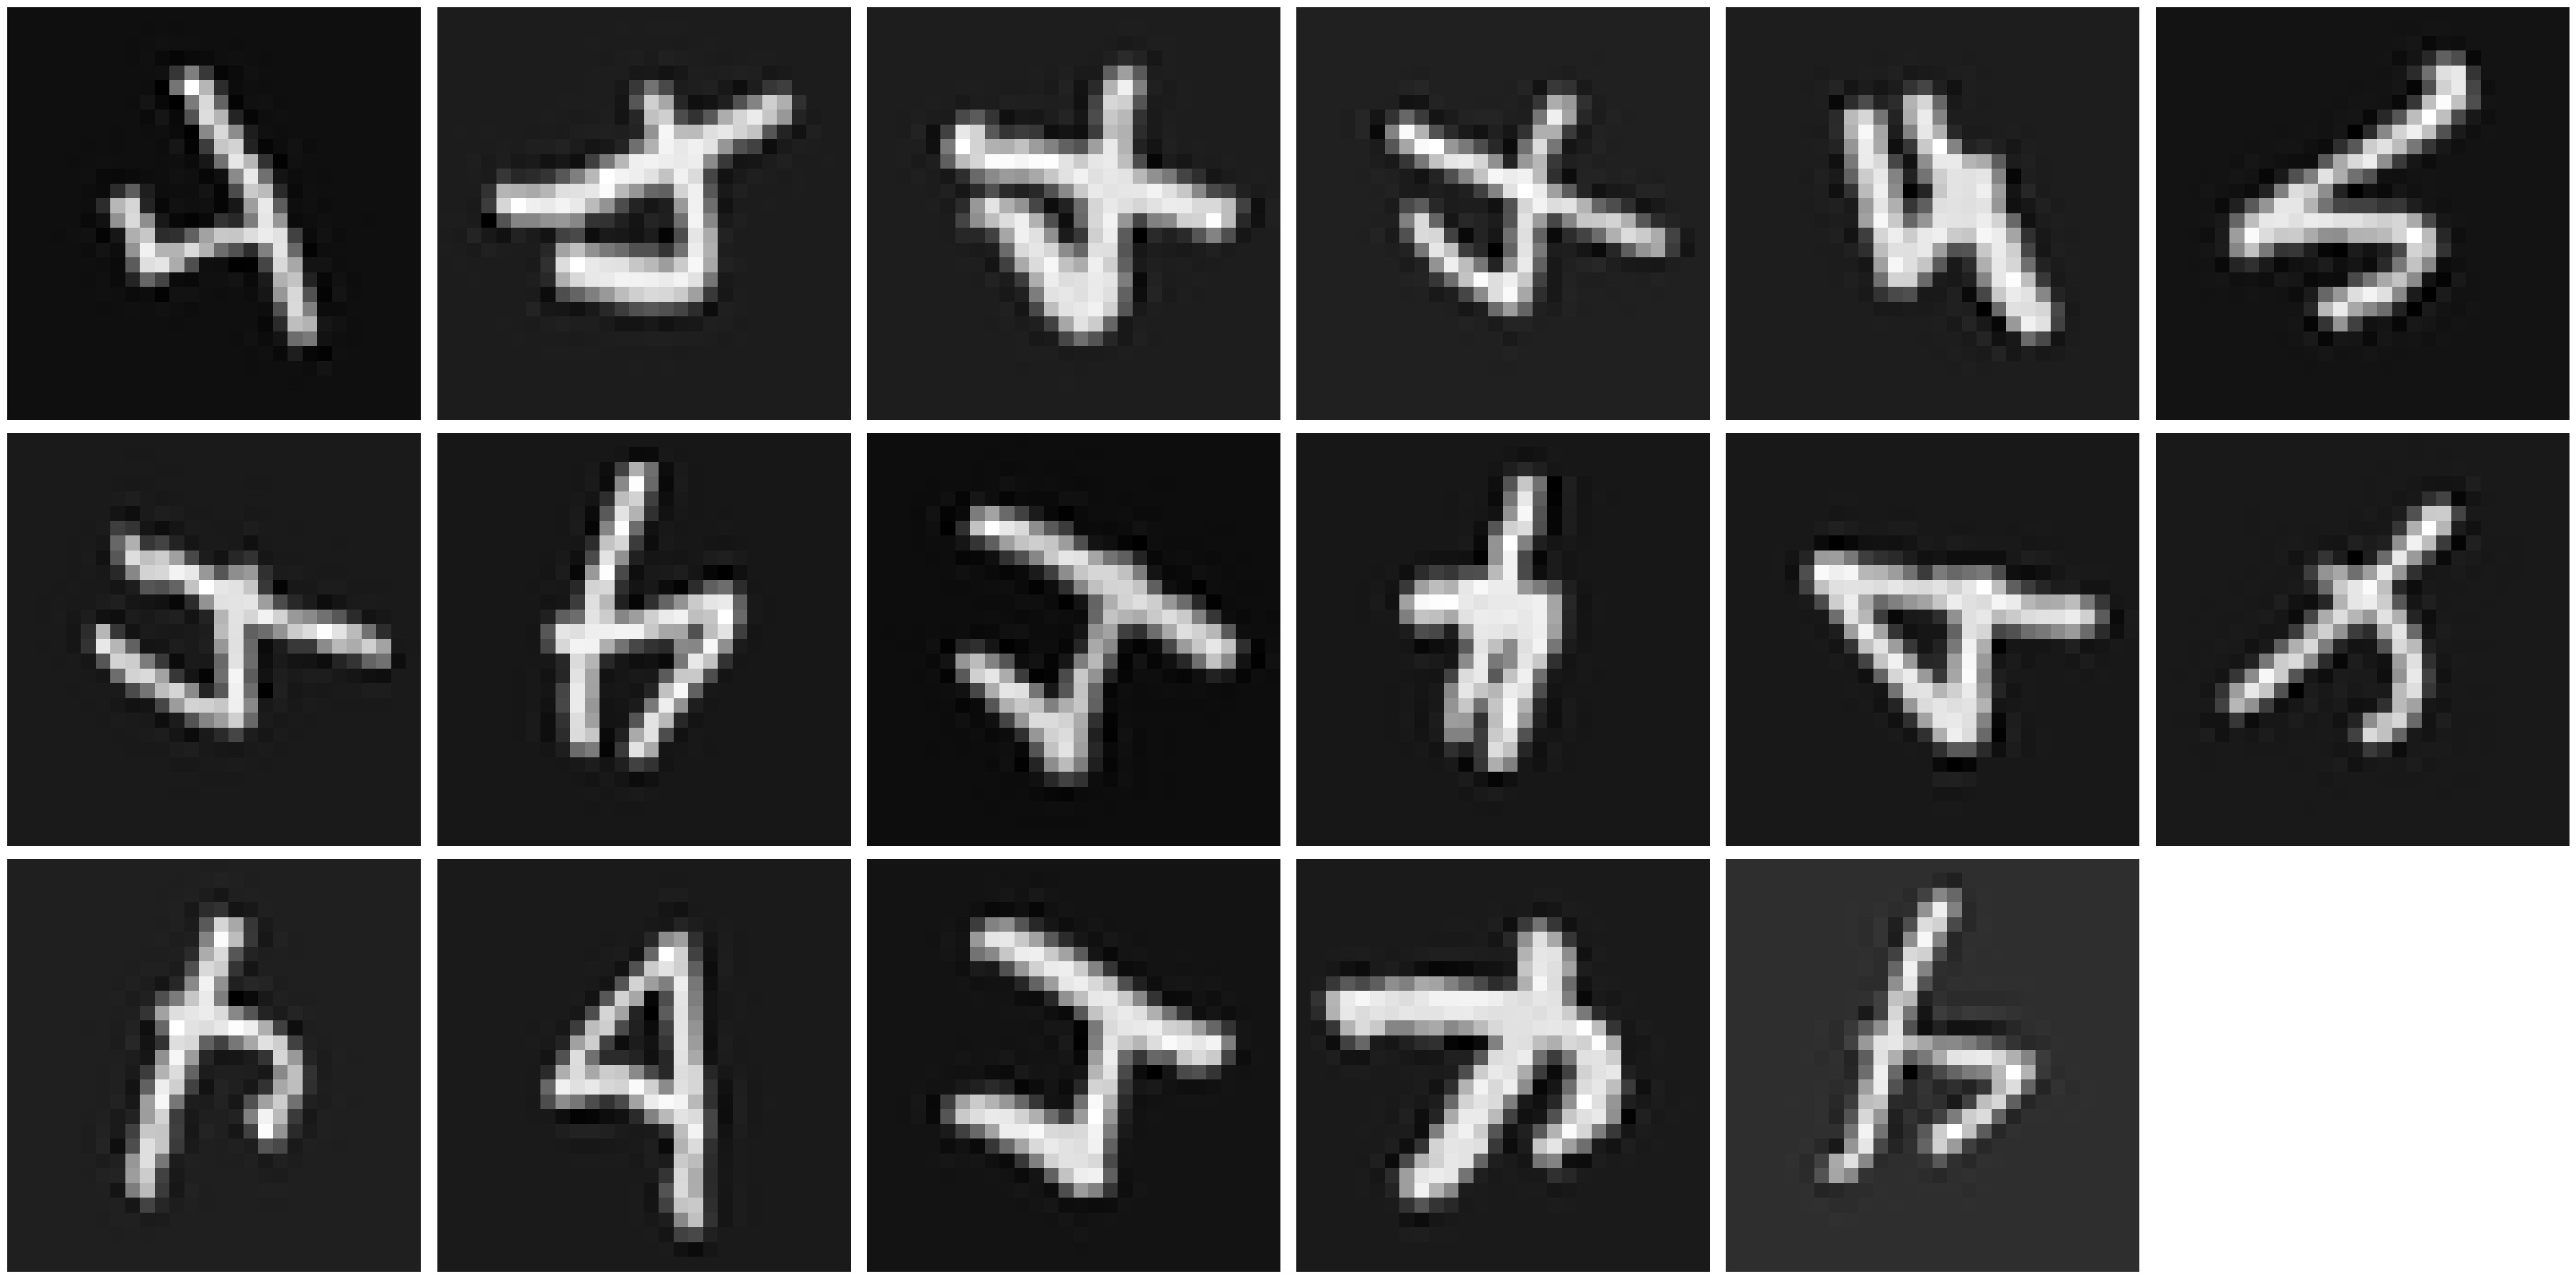

In [22]:
fours_with_homology = []
fours_with_homology_idx = []
for i, index in enumerate(subsample):
    if train.targets[index] == 4 and 4 in supports[i]:
        fours_with_homology.append(index)
        fours_with_homology_idx.append(i)

col_length = 6
n_rows = (len(fours_with_homology) + col_length - 1) // col_length
n_cols = min(col_length, len(fours_with_homology))
fig, ax = plt.subplots(figsize=(6*n_cols, 6*n_rows))
for i, index in enumerate(fours_with_homology):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(np.array(train_rotated[index][0]), cmap='gray')
    # plt.title(f"Explanation:\n" + ", ".join([F_names[j] for j in supports[fours_with_homology_idx[i]]]), fontsize=20)
    plt.axis('off')
ax.set_axis_off()
plt.tight_layout()
fig.savefig('../images/mnist_fours_with_homology.pdf')

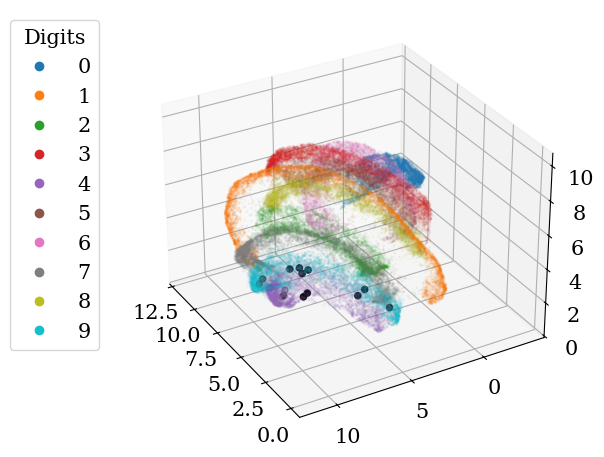

In [23]:
digits = [4,9,7]
feature = 4
digit_indices = np.where(np.isin(train.targets, digits))[0]
X_digit = X[digit_indices]

fig = plt.figure()
# scatter = ax.scatter(X_digit[:,0], X_digit[:,1], X_digit[:,2],
#                      c = F[digit_indices, feature],
#                      alpha = 0.01)
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(X[:,0], X[:,1], X[:,2], alpha = 0.05,
            c = train.targets, cmap = 'tab10', s = 1)
legend1 = ax.legend(*scatter.legend_elements(), title="Digits",
                    loc='upper left', bbox_to_anchor=(-0.3, 1.0))
for h in legend1.legend_handles:
    h.set_alpha(1)
ax.scatter(X[fours_with_homology,0], X[fours_with_homology,1], X[fours_with_homology,2],
                     c = 'black', s=20)
# ax.set_title(f"Digits {digits} colored by feature '{F_names[feature]}'")
ax.view_init(azim=150, elev=30)
plt.tight_layout()
fig.savefig('../images/mnist_fours_with_homology_umap.png', dpi=300, bbox_inches="tight")
plt.show()

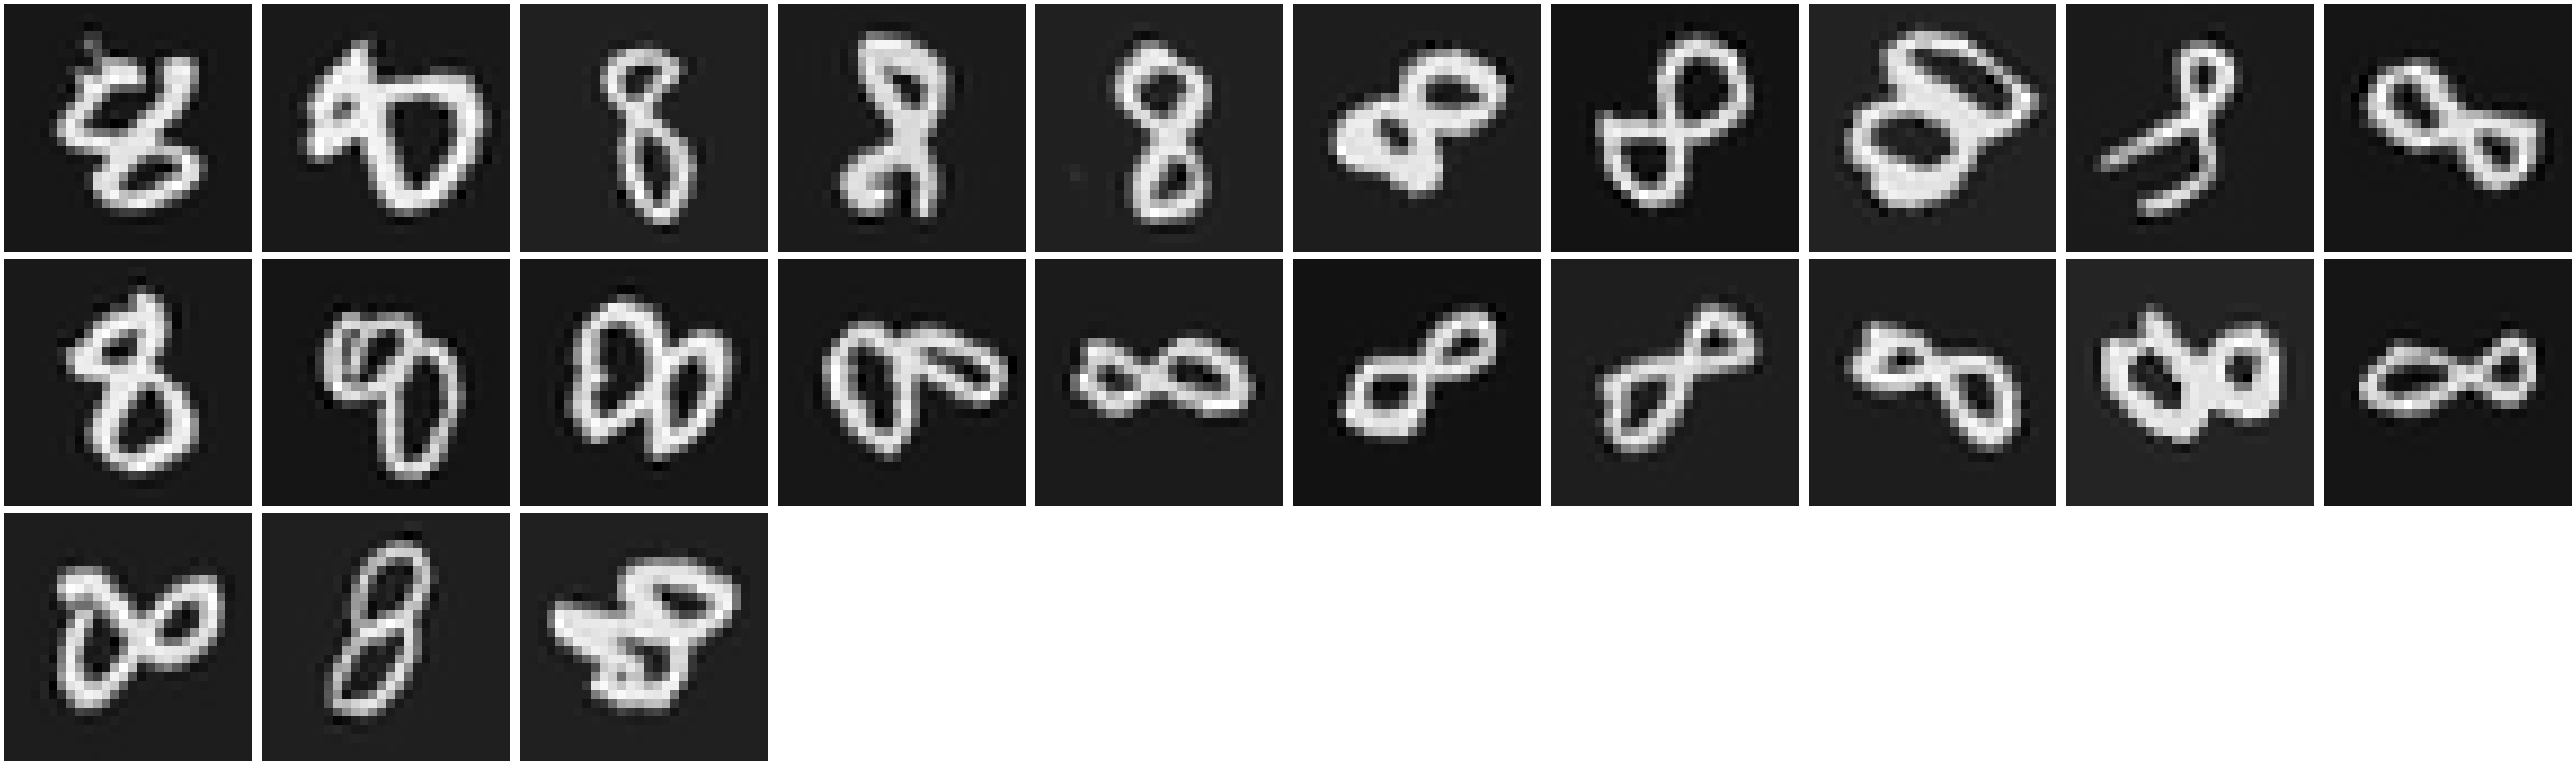

In [24]:
eights_with_homology = []
eights_with_homology_idx = []
for i, index in enumerate(subsample):
    if train.targets[index] == 8 and 5 in supports[i]:
        eights_with_homology.append(index)
        eights_with_homology_idx.append(i)

col_length = 10
n_rows = (len(eights_with_homology) + col_length - 1) // col_length
n_cols = min(col_length, len(eights_with_homology))
fig, ax = plt.subplots(figsize=(6*n_cols, 6*n_rows))
for i, index in enumerate(eights_with_homology):
    plt.subplot(n_rows, n_cols, i+1)
    plt.imshow(np.array(train_rotated[index][0]), cmap='gray')
    # plt.title(f"Explanation:\n" + ", ".join([F_names[j] for j in supports[eights_with_homology_idx[i]]]), fontsize=20)
    plt.axis('off')
ax.set_axis_off()
plt.tight_layout()
fig.savefig('../images/mnist_eights_with_homology.pdf')